In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
DEVICE

device(type='mps')

In [3]:
LOS = "bresenham"
VISION_RADIUS = 6

In [4]:
from matplotlib.pyplot import grid
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class SimplePolygonEnv(gym.Env):
    """Custom Environment that follows gymnasium interface"""
    
    def __init__(self, grid_dataset):
        super(SimplePolygonEnv, self).__init__()
        
        self.grid_dataset = grid_dataset # Pass your offline dataset here
        self.current_grid_idx = 0
        
        # Assume H=16, W=16 for this example. Change to your actual grid size.
        self.H, self.W = 16, 16 
        
        # ACTION SPACE: 4 Discrete Actions (0: Up, 1: Down, 2: Left, 3: Right)
        self.action_space = spaces.Discrete(4)
        self.action_mapping = {
            0: (-1, 0),  # Up
            1: (1, 0),   # Down
            2: (0, -1),  # Left
            3: (0, 1)    # Right
        }

        self.use_frontier_potential = False # Toggle for the global gravity reward
        
        # OBSERVATION SPACE: The exact 4-Channel tensor you feed your U-Net
        # Shape: (5, H, W), Values between 0.0 and 1.0
        self.observation_space = spaces.Box(
            low=0.0, high=np.inf, shape=(5, self.H, self.W), dtype=np.float32
        )
    
    def action_masks(self):
        """
        Returns a boolean array where True = Valid Action, False = Wall/Boundary.
        Order: [Up, Down, Left, Right] (matches your action_mapping)
        """
        mask = np.ones(4, dtype=bool)
        r, c = self.agent_pos
        
        for action_idx, (dr, dc) in self.action_mapping.items():
            nr, nc = r + dr, c + dc
            # If the neighbor is out of bounds OR is a wall, mask it out
            if not (0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0):
                mask[action_idx] = False
                
        return mask
    
    def _get_frontier_potential(self):
        """
        Calculates Manhattan distance to the nearest true frontier.
        Frontier: A known floor tile that orthogonally borders an unseen cell.
        """
        # 1. Identify Unseen cells
        unseen = (self.unseen_map == 1)
        
        # 2. Fast NumPy trick to find all cells that orthogonally border an unseen cell
        adj_unseen = np.zeros_like(unseen, dtype=bool)
        adj_unseen[:-1, :] |= unseen[1:, :]  # Check Up
        adj_unseen[1:, :] |= unseen[:-1, :]  # Check Down
        adj_unseen[:, :-1] |= unseen[:, 1:]  # Check Left
        adj_unseen[:, 1:] |= unseen[:, :-1]  # Check Right
        
        # 3. Apply your exact definition: Must be a floor (0), must be seen (0), and borders unseen
        is_known_floor = (self.grid == 0) & (self.unseen_map == 0)
        frontier_mask = is_known_floor & adj_unseen
        
        # Extract the coordinates of these specific frontier tiles
        frontier_coords = np.argwhere(frontier_mask)
        
        if len(frontier_coords) == 0:
            return 0 # Map is fully explored (or no frontiers exist)
            
        # 4. Calculate Manhattan distance from agent to all frontier tiles
        agent_r, agent_c = self.agent_pos
        distances = np.abs(frontier_coords[:, 0] - agent_r) + np.abs(frontier_coords[:, 1] - agent_c) + 1.0 # +1 to avoid division by zero and to give a small base potential even to adjacent frontiers
        
        total_potential = np.sum(1 / distances) # Closer frontiers contribute more to the potential
        return total_potential

    def _get_frontier_map(self):
        """
        Returns a binary map of the same size as the grid, where 1s indicate frontier tiles.
        Frontier: A known floor tile that orthogonally borders an unseen cell.
        """
        # 1. Identify Unseen cells
        unseen = (self.unseen_map == 1)
        
        # 2. Fast NumPy trick to find all cells that orthogonally border an unseen cell
        adj_unseen = np.zeros_like(unseen, dtype=bool)
        adj_unseen[:-1, :] |= unseen[1:, :]  # Check Up
        adj_unseen[1:, :] |= unseen[:-1, :]  # Check Down
        adj_unseen[:, :-1] |= unseen[:, 1:]  # Check Left
        adj_unseen[:, 1:] |= unseen[:, :-1]  # Check Right
        
        # 3. Apply your exact definition: Must be a floor (0), must be seen (0), and borders unseen
        is_known_floor = (self.grid == 0) & (self.unseen_map == 0)
        frontier_mask = is_known_floor & adj_unseen
        
        return frontier_mask.astype(np.float32) # Convert boolean mask to float32 for neural network compatibility

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # 1. Load a random grid from your dataset
        self.grid = self.grid_dataset[np.random.randint(len(self.grid_dataset))]
        
        # 2. Spawn agent on a random clear floor tile
        free_cells = np.argwhere(self.grid == 0)
        spawn_idx = np.random.choice(len(free_cells))
        self.agent_pos = tuple(free_cells[spawn_idx])
        self.path = [self.agent_pos]
        self.cells_revealed_per_step = []
        
        # 3. Initialize Memory Maps
        self.known_obstacles = np.zeros_like(self.grid, dtype=np.float32)
        self.unseen_map = np.ones_like(self.grid, dtype=np.float32)
        # --- NEW BREADCRUMB MEMORY ---
        self.visit_count = np.zeros_like(self.grid, dtype=np.float32)
        
        self.step_count = 0
        self.max_steps = 256
        
        # 4. Generate initial observation
        obs = self._get_obs()
        
        if self.use_frontier_potential:
            self.previous_potential = self._get_frontier_potential() # For the global gravity reward
        # Gymnasium v0.26+ requires returning (observation, info_dict)
        return obs, {}

    def step(self, action):
        self.step_count += 1
        
        if isinstance(action, np.ndarray):
            action = action.item()
        # 1. Attempt to move the agent
        dr, dc = self.action_mapping[action]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc
        
        reward = -0.1 # Base time penalty (punishes dithering/hesitation)

         # 5. Check Termination Conditions
        terminated = False
        truncated = False
        
        # 2. Check collision
        if 0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0:
            # Valid move
            self.agent_pos = (nr, nc)
           
            self.path.append(self.agent_pos)
            
            # --- THE REVISIT PENALTY ---
            # If we have been here before, penalize it heavily. 
            # 1st visit = 0 penalty. 2nd visit = -0.1. 3rd visit = -0.2. etc.
            visits = self.visit_count[nr, nc]
            reward -= ((visits ** 2) * 0.9) #exponential penalty for repeated visits
            self.visit_count[nr, nc] += 1

            
            # ---------------------------
        else:
            reward -= 10 # Wall collision
            self.path.append(self.agent_pos) # Even if we hit a wall, we "visit" that cell for LOS purposes
            path_length_untill_now = len(self.path)
            self.path.extend((self.max_steps - path_length_untill_now) * [self.agent_pos]) # Pad the path to max length to avoid issues in the replay buffer
            self.step_count = self.max_steps # Force end of episode
            terminated = True

        # 3. Update Maps & Calculate New Information
        previous_unseen_count = self.unseen_map.sum()
        obs = self._get_obs() # This calls your LOS and Grazing functions
        current_unseen_count = self.unseen_map.sum()
        
        
        # 4. Reward Shaping: Reward the agent for discovering new floor
        cells_revealed = previous_unseen_count - current_unseen_count
        if cells_revealed >= 0:
            reward += cells_revealed * 5.0
            self.cells_revealed_per_step.append(cells_revealed)

        if self.use_frontier_potential:
            # --- THE GLOBAL GRAVITY REWARD ---
            current_potential = self._get_frontier_potential()
            # Did the global pull get stronger (we moved closer) or weaker (we moved away)?
            potential_change = current_potential - self.previous_potential
            # potential_change is POSITIVE if we got closer to the fog mass (Good)
            # potential_change is NEGATIVE if we moved further away (Bad)
            reward += (potential_change * 10) # You may need to tune this multiplier!
            
            self.previous_potential = current_potential
            # ---------------------------------
            
        # 2. The Exact Termination Condition
        unseen_floor_count = np.sum(self.unseen_map[self.grid == 0])
        
        # Did we explore everything?
        if unseen_floor_count == 0:  
            terminated = True
            # --- THE SPEED BONUS ---
            # Max possible steps is self.max_steps. We reward the agent for unused time.
            steps_remaining = self.max_steps - self.step_count
            
            # Base completion (+10) plus a scaling bonus for speed (e.g., +0.1 per saved step)
            speed_bonus = steps_remaining * 0.1
            reward += (50.0 + speed_bonus)
            
        # Did we run out of time? (e.g., trapped in a loop)
        if self.step_count >= self.max_steps:
            truncated = True

        return obs, float(reward), terminated, truncated, {"path": self.path, "cells_revealed": self.cells_revealed_per_step, "reward": reward}

    def _get_obs(self):
        """Builds the 3-channel state tensor identically to your U-Net"""
        agent_layer = np.zeros_like(self.grid, dtype=np.float32)
        agent_layer[self.agent_pos] = 1.0
        
        # NOTE: Call your exact LOS functions here
        expanded_los = get_visibility_map_with_LOS(self.grid, self.path, grazing_walls=True, los_type=LOS, vision_radius=VISION_RADIUS, with_last_obstacle=True)
        # For boilerplate, assuming expanded_los is calculated:
        self.unseen_map[expanded_los == 1] = 0.0
        visible_walls = expanded_los & (self.grid == 1)
        self.known_obstacles[visible_walls] = 1.0
        self.frontier_map = self._get_frontier_map() # Get the frontier map for the current state

        # Normalize the visit count so the neural network can read it safely [0.0 to 1.0]
        # (Assuming it rarely visits a single cell more than 10 times if exploring optimally)
        visit_heatmap = self.visit_count / 10.0
        
        state_tensor = np.stack([
            self.known_obstacles, 
            agent_layer, 
            self.unseen_map, 
            visit_heatmap, # <-- The new 4th channel
            self.frontier_map # <-- The new 5th channel
        ], axis=0)
        
        return state_tensor

In [5]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from autoregressive_unet import ResidualConv

class CustomGridCNN(BaseFeaturesExtractor):
    """
    A custom CNN tailored for tiny 16x16 grids.
    """

    def _get_coord_channels(self, batch_size, height, width, device):
        """Generates normalized coordinate channels"""
        y_coords = torch.linspace(-1, 1, steps=height, device=device).view(1, 1, height, 1).expand(batch_size, 1, height, width)
        x_coords = torch.linspace(-1, 1, steps=width, device=device).view(1, 1, 1, width).expand(batch_size, 1, height, width)
        return x_coords, y_coords
    
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 512):
        super(CustomGridCNN, self).__init__(observation_space, features_dim)
        
        n_input_channels = observation_space.shape[0] + 2  # Original channels + 2 for coordinates
        
        self.cnn = nn.Sequential(
            # 16x16 -> 16x16
            nn.Conv2d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            # nn.BatchNorm2d(32),
            nn.ReLU(),
            # 16x16 -> 8x8
            nn.MaxPool2d(2),
            # 8x8 -> 8x8
            nn.Conv2d(32, 128, kernel_size=3, stride=1, padding=1),
            # nn.BatchNorm2d(128),
            nn.ReLU(),
            # 8x8 -> 4x4
            nn.MaxPool2d(2),
            nn.Flatten(),
        )

        # Compute shape by doing one forward pass with dummy data
        with torch.no_grad():
            dummy_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            batch_size, _, height, width = dummy_tensor.shape
            device = dummy_tensor.device
            x_coords, y_coords = self._get_coord_channels(batch_size, height, width, device)
            dummy_tensor = torch.cat([dummy_tensor, x_coords, y_coords], dim=1)
            n_flatten = self.cnn(dummy_tensor).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim), 
            nn.ReLU()
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        batch_size, _, height, width = observations.shape
        device = observations.device
        x_coords, y_coords = self._get_coord_channels(batch_size, height, width, device)
        observations_ = torch.cat([observations, x_coords, y_coords], dim=1)
        return self.linear(self.cnn(observations_))

Generated Grid:


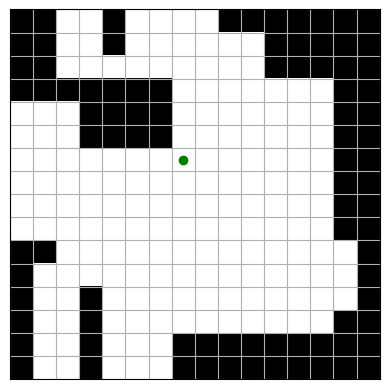

In [6]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
# grid, start = gen.generate_valid_grid(density=5)
grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


In [7]:
N = 20_000
grid_dataset = []
for _i in range(N):
    grid, start = gen.generate_simple_polygon_grid()
    grid_dataset.append(grid)
np.array(grid_dataset).shape

(20000, 16, 16)

In [8]:

def apply_dihedral8_augmentation(grid_daatset):
    augmented_dataset = []
    for grid in grid_daatset:
        # Original
        augmented_dataset.append(grid)
        # Rotate 90
        augmented_dataset.append(np.rot90(grid, k=1))
        # Rotate 180
        augmented_dataset.append(np.rot90(grid, k=2))
        # Rotate 270
        augmented_dataset.append(np.rot90(grid, k=3))
        # Flip horizontally
        augmented_dataset.append(np.fliplr(grid))
        # Flip vertically
        augmented_dataset.append(np.flipud(grid))
        # Flip across main diagonal
        augmented_dataset.append(np.transpose(grid))
        # Flip across anti-diagonal
        augmented_dataset.append(np.fliplr(np.transpose(grid)))
    return np.array(augmented_dataset)
augmented_grid_dataset = apply_dihedral8_augmentation(grid_dataset)
print("Original dataset size:", len(grid_dataset))
print("Augmented dataset size:", len(augmented_grid_dataset))

Original dataset size: 20000
Augmented dataset size: 160000


In [9]:
# import stable_baselines3
# stable_baselines3.common.env_checker.check_env(SimplePolygonEnv(grid_dataset=grid_dataset), warn=True)

In [10]:
# from stable_baselines3 import PPO

# # Tell SB3 to use your CustomGridCNN instead of NatureCNN
# policy_kwargs = dict(
#     features_extractor_class=CustomGridCNN,
#     features_extractor_kwargs=dict(features_dim=512),
# )

# env = SimplePolygonEnv(grid_dataset=grid_dataset)

# print("Starting PPO Training with Custom CNN...")
# model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1, learning_rate=0.0003)

# model.learn(total_timesteps=5_000_000, progress_bar=True, log_interval=100)

In [11]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.maskable.evaluation import evaluate_policy
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.callbacks import (
    CheckpointCallback,
    EvalCallback
)

# 1. Initialize the environment
env = SimplePolygonEnv(grid_dataset=augmented_grid_dataset)
eval_env = SimplePolygonEnv(grid_dataset=grid_dataset) # Separate env for evaluation to avoid data leakage
env = ActionMasker(env, action_mask_fn=lambda env: env.action_masks())
policy_kwargs = dict(
    features_extractor_class=CustomGridCNN,
    features_extractor_kwargs=dict(features_dim=256),
)
# 2. Setup the Maskable PPO model
# Note: Use 'MultiInputPolicy' if you have complex obs, 
# or 'CnnPolicy' for your current grid setup.
model = MaskablePPO(
    "CnnPolicy", 
    env, 
    policy_kwargs=policy_kwargs, 
    verbose=1, 
    learning_rate=0.0003, 
    device = "mps"
)
# 3. Train
model.learn(
    total_timesteps=500_000,
    progress_bar=True,
    log_interval=50,
)

Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Output()

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 242         |
|    ep_rew_mean          | -9.75e+03   |
| time/                   |             |
|    fps                  | 28          |
|    iterations           | 50          |
|    time_elapsed         | 3557        |
|    total_timesteps      | 102400      |
| train/                  |             |
|    approx_kl            | 0.007083363 |
|    clip_fraction        | 0.0354      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.22       |
|    explained_variance   | 0           |
|    learning_rate        | 0.0003      |
|    loss                 | 1.3e+05     |
|    n_updates            | 490         |
|    policy_gradient_loss | -0.00471    |
|    value_loss           | 2.76e+05    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 201         |
|    ep_rew_mean          | -520        |
| time/                   |             |
|    fps                  | 26          |
|    iterations           | 100         |
|    time_elapsed         | 7674        |
|    total_timesteps      | 204800      |
| train/                  |             |
|    approx_kl            | 0.005316564 |
|    clip_fraction        | 0.04        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.23       |
|    explained_variance   | 0.781       |
|    learning_rate        | 0.0003      |
|    loss                 | 576         |
|    n_updates            | 990         |
|    policy_gradient_loss | -0.00399    |
|    value_loss           | 1.8e+03     |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 204          |
|    ep_rew_mean          | -550         |
| time/                   |              |
|    fps                  | 17           |
|    iterations           | 150          |
|    time_elapsed         | 17591        |
|    total_timesteps      | 307200       |
| train/                  |              |
|    approx_kl            | 0.0058685383 |
|    clip_fraction        | 0.0368       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.21        |
|    explained_variance   | 0.791        |
|    learning_rate        | 0.0003       |
|    loss                 | 2.72e+03     |
|    n_updates            | 1490         |
|    policy_gradient_loss | -0.00381     |
|    value_loss           | 7.42e+03     |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 212         |
|    ep_rew_mean          | -2e+03      |
| time/                   |             |
|    fps                  | 19          |
|    iterations           | 200         |
|    time_elapsed         | 20885       |
|    total_timesteps      | 409600      |
| train/                  |             |
|    approx_kl            | 0.006199462 |
|    clip_fraction        | 0.0338      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.24       |
|    explained_variance   | 0.159       |
|    learning_rate        | 0.0003      |
|    loss                 | 5.62e+05    |
|    n_updates            | 1990        |
|    policy_gradient_loss | -0.00182    |
|    value_loss           | 1.67e+06    |
-----------------------------------------


In [12]:
import numpy as np
from stable_baselines3 import PPO

# # 1. Load the RAW test dataset (Ground truth grids, not X_test/y_test tensors)
# # Assuming you have 750 raw test grids based on your previous data
# raw_test_grids = np.load("data/raw_simple_polygons_test.npy") 
# 2. Initialize the environment with the TEST data

rand = random.randint(0, 10000)
size = 100
eval_grid_dataset = grid_dataset[rand:rand+size]  # Use the first 500 grids as your test set
eval_env = SimplePolygonEnv(grid_dataset=eval_grid_dataset)

# 3. Load the trained model
# Replace with your actual saved model path
# model = PPO.load("ppo_baseline_agent")

ppo_path_lengths = []
success_count = 0
success_count_95 = 0
success_count_99 = 0
success_count_100 = 0

print(f"Evaluating PPO Baseline on {len(eval_grid_dataset)} test environments...")

for i in range(len(eval_grid_dataset)):
    # Force the environment to use the specific test grid sequentially
    eval_env.grid_dataset = [eval_grid_dataset[i]] 
    obs, info = eval_env.reset()
    
    done = False
    steps_taken = 0
    
    while not done:
        # deterministic=True forces the agent to take the action with the highest probability
        action_mask = get_action_masks(eval_env)
        action, _states = model.predict(obs, deterministic=True, action_masks=action_mask)
        
        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        steps_taken += 1
        
        if terminated or truncated:
            done = True
            ppo_path_lengths.append(steps_taken)
            if terminated:
                success_count += 1
    
    # Track 95%, 99% exploration as well
    total_floor = np.sum(eval_env.grid_dataset[0] == 0)
    unseen_floor = np.sum(eval_env.unseen_map[eval_env.grid == 0])
    explored_percentage = ((total_floor - unseen_floor) / total_floor) * 100
    if explored_percentage >= 95.0:
        success_count_95 += 1
    if explored_percentage >= 99.0:
        success_count_99 += 1
    if explored_percentage >= 100.0:
        success_count_100 += 1

    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(eval_grid_dataset)} grids...")

# --- THE FINAL METRICS ---
print("\n--- PPO Baseline Results ---")
print(f"Total Successes (Explored 100%): {success_count} / {len(eval_grid_dataset)}")
print(f"Success Rate: {(success_count / len(eval_grid_dataset)) * 100:.2f}%")
print(f"Average Path Length (including timeouts): {np.mean(ppo_path_lengths):.2f}")

print("-- Additional Exploration Metrics ---")
print(f"Successes (Explored >= 95%): {success_count_95} / {len(eval_grid_dataset)}")
print(f"Successes (Explored >= 99%): {success_count_99} / {len(eval_grid_dataset)}")
print(f"Successes (Explored 100%): {success_count_100} / {len(eval_grid_dataset)}")

Evaluating PPO Baseline on 100 test environments...
Evaluated 50/100 grids...
Evaluated 100/100 grids...

--- PPO Baseline Results ---
Total Successes (Explored 100%): 70 / 100
Success Rate: 70.00%
Average Path Length (including timeouts): 179.28
-- Additional Exploration Metrics ---
Successes (Explored >= 95%): 92 / 100
Successes (Explored >= 99%): 79 / 100
Successes (Explored 100%): 70 / 100


In [35]:
# model.save("model_ppo_baseline_agent_500k_steps_noBatchNorm")

from sb3_contrib import MaskablePPO

env = SimplePolygonEnv(grid_dataset=augmented_grid_dataset)
env = ActionMasker(env, action_mask_fn=lambda env: env.action_masks())

loaded_model = MaskablePPO.load(
    "model_ppo_baseline_agent_500k_steps_noBatchNorm.zip",
    env=env,
    device="mps"  # or "cpu"
)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [39]:
model = loaded_model

In [ ]:
grid, start = gen.generate_simple_polygon_grid()


Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent is oscillating and cannot make progress.
Agent successfully explored the entire grid!
Explored Percentage: 100.00%
Path Length: 156


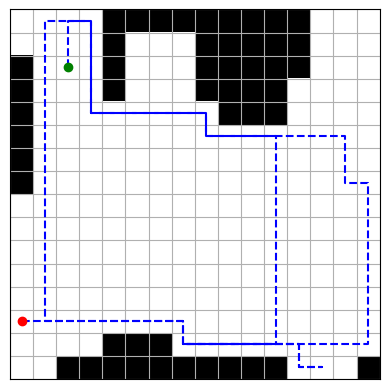

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO



eval_env = SimplePolygonEnv(grid_dataset=[grid]) # Wrap in a list to create a dataset with one grid
oscillation_threshold = 6
oscillation_counter = 0
previous_positions = []

obs, info = eval_env.reset()
grid = eval_env.grid

done = False
while not done:
    action_mask = get_action_masks(eval_env)
    # print("Action Mask:", action_mask)
    action, _states = model.predict(obs, deterministic=True, action_masks=action_mask)
    obs, reward, terminated, truncated, info = eval_env.step(action)

    previous_positions.append(info['path'][-1]) # Track the agent's current position
    if len(previous_positions) > oscillation_threshold:
        previous_positions.pop(0)
        if len(set(previous_positions)) <= 2:
            oscillation_counter += 1
        else:
            oscillation_counter = 0

    if terminated or truncated or oscillation_counter >= oscillation_threshold:
        done = True
        if terminated:
            print("Agent successfully explored the entire grid!")
        elif oscillation_counter >= oscillation_threshold:
            done = False
            print("Agent is oscillating and cannot make progress.")
        else:
            print("Agent failed to explore the entire grid within the step limit.")

# Extract the path it took
total_floor = np.sum(eval_env.grid_dataset[0] == 0)
unseen_floor = np.sum(eval_env.unseen_map[eval_env.grid == 0])
explored_percentage = ((total_floor - unseen_floor) / total_floor) * 100
print(f"Explored Percentage: {explored_percentage:.2f}%")
path = info['path']

plot_path(grid, path)
print("Path Length:", len(path))

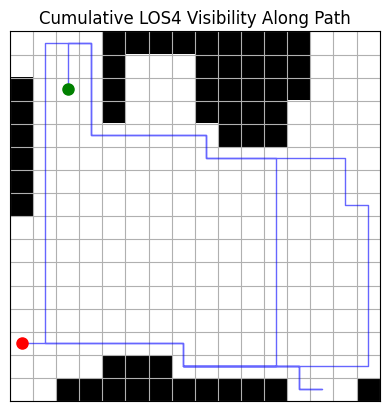

In [77]:
plot_visibility(grid, path)

In [ ]:
def get_percentage_explored(env):
    

In [76]:
path

[(np.int64(2), np.int64(2)),
 (np.int64(1), np.int64(2)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(0), np.int64(3)),
 (np.int64(1), np.int64(3)),
 (np.int64(2), np.int64(3)),
 (np.int64(3), np.int64(3)),
 (np.int64(4), np.int64(3)),
 (np.int64(4), np.int64(4)),
 (np.int64(4), np.int64(5)),
 (np.int64(4), np.int64(6)),
 (np.int64(4), np.int64(7)),
 (np.int64(4), np.int64(8)),
 (np.int64(5), np.int64(8)),
 (np.int64(5), np.int64(9)),
 (np.int64(5), np.int64(10)),
 (np.int64(5), np.int64(11)),
 (np.int64(6), np.int64(11)),
 (np.int64(

In [38]:
len(path)

58

In [30]:
info["reward"]

np.float64(-10.1)

In [31]:
info["cells_revealed"]

[np.float32(15.0),
 np.float32(20.0),
 np.float32(12.0),
 np.float32(12.0),
 np.float32(4.0)]

In [85]:
len(info["cells_revealed"])
path[:23]

[(np.int64(13), np.int64(1)),
 (np.int64(13), np.int64(2)),
 (np.int64(13), np.int64(3)),
 (np.int64(13), np.int64(4)),
 (np.int64(13), np.int64(5)),
 (np.int64(13), np.int64(6)),
 (np.int64(13), np.int64(7)),
 (np.int64(13), np.int64(8)),
 (np.int64(13), np.int64(9)),
 (np.int64(13), np.int64(10)),
 (np.int64(13), np.int64(11)),
 (np.int64(13), np.int64(12)),
 (np.int64(12), np.int64(12)),
 (np.int64(11), np.int64(12)),
 (np.int64(10), np.int64(12)),
 (np.int64(9), np.int64(12)),
 (np.int64(8), np.int64(12)),
 (np.int64(7), np.int64(12)),
 (np.int64(6), np.int64(12)),
 (np.int64(5), np.int64(12)),
 (np.int64(4), np.int64(12)),
 (np.int64(3), np.int64(12)),
 (np.int64(3), np.int64(12))]